# Project Overall
This project uses a real-world dataset (likely from a UK-based non-store online retail) to understand the financial health and operational patterns of the business. You are moving from Data Preparation (cleaning "dirty" data like negative quantities and null values) to Strategic Analysis (identifying who buys what, when, and where).

# Initializing the environment by importing pandas and numpy, and loading the raw retail dataset to inspect the first few rows.

In [1]:
import pandas as pd
import numpy as np 


In [2]:
df = pd.read_csv('Online_Retail.csv')
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


# Generating descriptive statistics for all columns to identify data ranges, potential outliers (like negative quantities), and missing values.

In [5]:
df.describe(include ="all")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,10/31/11 14:41,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,NaN,4.611114,15287.690570,NaN
std,NaN,NaN,NaN,218.081158,NaN,96.759853,1713.600303,NaN
min,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,16791.000000,NaN


# Identifying missing data; specifically highlights significant gaps in CustomerID and Description

In [11]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

# Examining unique values and the total row count of the Quantity column to understand the scale of the data.

In [6]:
df.Quantity.unique()

array([     6,      8,      2,     32,      3,      4,     24,     12,
           48,     18,     20,     36,     80,     64,     10,    120,
           96,     23,      5,      1,     -1,     50,     40,    100,
          192,    432,    144,    288,    -12,    -24,     16,      9,
          128,     25,     30,     28,      7,     56,     72,    200,
          600,    480,     -6,     14,     -2,     11,     33,     13,
           -4,     -5,     -7,     -3,     70,    252,     60,    216,
          384,    -10,     27,     15,     22,     19,     17,     21,
           34,     47,    108,     52,  -9360,    -38,     75,    270,
           42,    240,     90,    320,   1824,    204,     69,    -36,
         -192,   -144,    160,   2880,   1400,     39,    -48,    -50,
           26,   1440,     31,     82,     78,     97,     98,     35,
           57,    -20,    110,    -22,    -30,    -70,   -130,    -80,
         -120,    -40,    -25,    -14,    -15,    -69,   -140,   -320,
      

In [8]:
df.Quantity.shape

(541909,)

# Creating a flag for negative quantities (likely returns or adjustments) and counting them to assess data "noise.

In [15]:
df['negetive_Quantity']= df['Quantity']<1
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,negetive_Quantity
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom,False
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom,False


In [23]:
df['negetive_Quantity'].value_counts()

negetive_Quantity
False    531285
True      10624
Name: count, dtype: int64

# Removing the temporary flag column and verifying the dataframe structure.

In [24]:
df.drop(columns=['negetive_Quantity'], inplace=True)


In [26]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


# Filtering the dataset to include only transactions with a Quantity > 1 to focus on actual sales and reduce bulk return bias.

In [31]:
df = df[df['Quantity'] >1]

In [32]:
df.Quantity.unique()

array([    6,     8,     2,    32,     3,     4,    24,    12,    48,
          18,    20,    36,    80,    64,    10,   120,    96,    23,
           5,    50,    40,   100,   192,   432,   144,   288,    16,
           9,   128,    25,    30,    28,     7,    56,    72,   200,
         600,   480,    14,    11,    33,    13,    70,   252,    60,
         216,   384,    27,    15,    22,    19,    17,    21,    34,
          47,   108,    52,    75,   270,    42,   240,    90,   320,
        1824,   204,    69,   160,  2880,  1400,    39,    26,  1440,
          31,    82,    78,    97,    98,    35,    57,   110,   720,
         156,   324,    38,    37,    49,    95,    29,    41,   402,
         378,   150,   300,    54,   104,    67,   258,    66,    44,
          55,    46,    99,    61,   408,   972,   208,  1008,  1000,
        1488,   250,  1394,   400,    79,    84,   272,   113,    45,
         106,    68,   267,   115,    65,  1728,    53,    76,   460,
          71,    43,

In [33]:
df.Quantity.shape

(383058,)

In [34]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

# Ensuring all UnitPrice values are non-negative and verifying the resulting dataset size.

In [35]:
df.UnitPrice.unique()

array([2.550e+00, 3.390e+00, 2.750e+00, 7.650e+00, 4.250e+00, 1.850e+00,
       1.690e+00, 2.100e+00, 3.750e+00, 1.650e+00, 4.950e+00, 9.950e+00,
       5.950e+00, 7.950e+00, 8.500e-01, 6.500e-01, 1.250e+00, 2.950e+00,
       1.950e+00, 4.200e-01, 1.800e+01, 1.060e+00, 6.950e+00, 1.095e+01,
       3.450e+00, 5.500e-01, 3.800e-01, 1.450e+00, 3.950e+00, 6.750e+00,
       1.495e+01, 1.695e+01, 6.450e+00, 1.275e+01, 8.500e+00, 3.820e+00,
       3.370e+00, 5.450e+00, 6.350e+00, 7.200e-01, 6.400e-01, 1.000e-01,
       3.200e-01, 1.480e+00, 3.575e+01, 4.650e+00, 2.900e-01, 3.350e+00,
       9.500e-01, 2.100e-01, 1.200e-01, 0.000e+00, 2.400e-01, 1.490e+00,
       1.550e+00, 3.250e+00, 2.250e+00, 8.950e+00, 2.510e+00, 1.660e+00,
       4.300e-01, 2.980e+00, 5.910e+00, 3.360e+00, 7.620e+00, 1.698e+01,
       1.102e+01, 8.470e+00, 4.210e+00, 8.100e-01, 1.280e+00, 5.060e+00,
       1.272e+01, 6.770e+00, 9.320e+00, 8.400e-01, 1.017e+01, 1.187e+01,
       1.995e+01, 4.600e+00, 1.050e+00, 1.357e+01, 

In [37]:
df.UnitPrice.shape

(383058,)

In [38]:
df = df[df['UnitPrice'] >= 0]

0.0


In [39]:
df.UnitPrice.shape

(383058,)

In [40]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,383058.000000,383058.000000,324610.000000
mean,14.391434,2.782704,15199.208296
std,184.562297,3.414330,1715.276043
min,2.000000,0.000000,12346.000000
25%,3.000000,1.250000,13767.000000
50%,6.000000,1.790000,15051.000000
75%,12.000000,3.750000,16717.000000
max,80995.000000,649.500000,18287.000000


# Converting InvoiceDate to a datetime object and extracting Year, Month, and Day for time-series analysis.

In [45]:
# 1. Convert the column to datetime objects
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


In [46]:
df['Year'] = df['InvoiceDate'].dt.year

In [48]:
df['Month'] = df['InvoiceDate'].dt.month

In [49]:
df['Day'] = df['InvoiceDate'].dt.day

In [50]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Year,Month,Day
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1


# Creating a Revenue column ($Quantity \times UnitPrice$) to measure the financial impact of each transaction.

In [54]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [55]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Year,Month,Day,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,1,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12,1,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,20.34


# Plotting monthly revenue for 2011 to identify seasonal peaks and growth patterns.

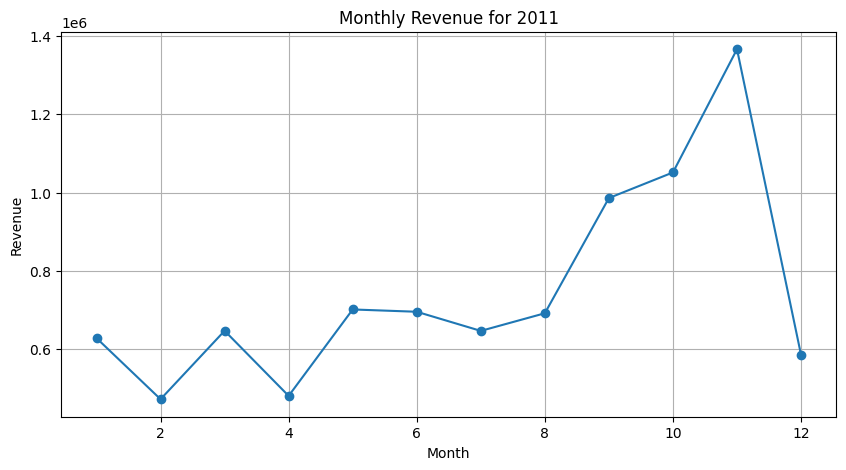

In [56]:
import matplotlib.pyplot as plt
df_2011 = df[df['Year'] == 2011]
monthly_revenue = df_2011.groupby('Month')['Revenue'].sum()
monthly_revenue.plot(kind='line', marker='o', figsize=(10, 5))
plt.title('Monthly Revenue for 2011')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

# Insight: There is a clear upward trend in the latter half of the year. Revenue spikes significantly starting in September, peaking in November. This suggests strong seasonal demand likely driven by holiday shopping (Q4).

# Visualizing the top 10 international markets (excluding the UK) by revenue and volume to identify key expansion zones

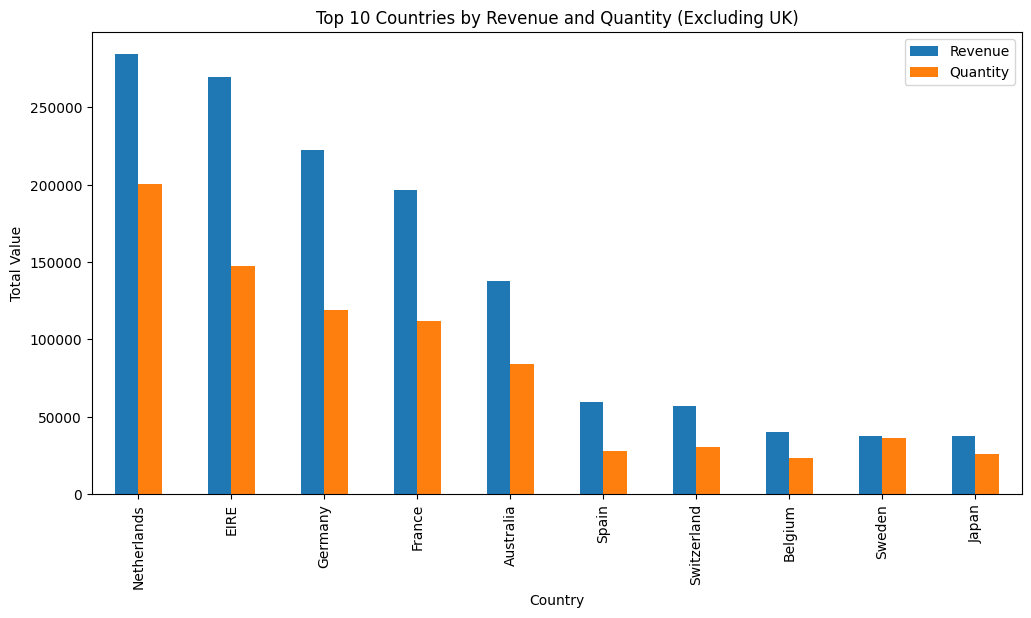

In [57]:
# Filter out United Kingdom
df_no_uk = df[df['Country'] != 'United Kingdom']
top_countries = df_no_uk.groupby('Country')[['Revenue', 'Quantity']].sum().sort_values(by='Revenue', ascending=False).head(10)
top_countries.plot(kind='bar', figsize=(12, 6))
plt.title('Top 10 Countries by Revenue and Quantity (Excluding UK)')
plt.ylabel('Total Value')
plt.show()

# The Netherlands, EIRE (Ireland), and Germany are the leading international markets. The gap between the Netherlands and the others suggests a highly concentrated or wholesale-heavy customer base in that region.

# Identifying the top 10 customers by total spend to highlight high-value accounts.

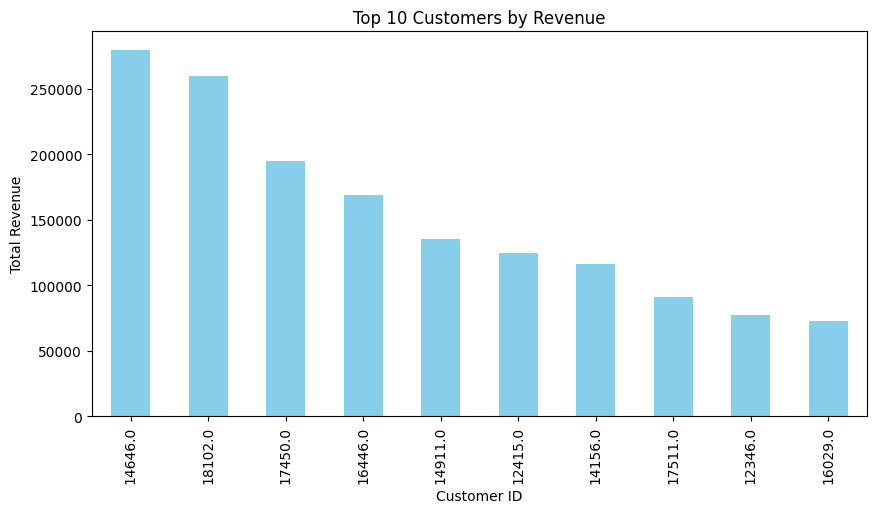

In [58]:
# Group by CustomerID and sum Revenue
top_customers = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)

# Plotting
top_customers.plot(kind='bar', color='skyblue', figsize=(10, 5))
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Total Revenue')
plt.show()

# Insight: The revenue distribution among top customers shows a "long tail." A small group of Customer IDs contributes a disproportionately high amount of total revenue, indicating these are likely B2B or wholesale clients rather than individual retail shoppers.

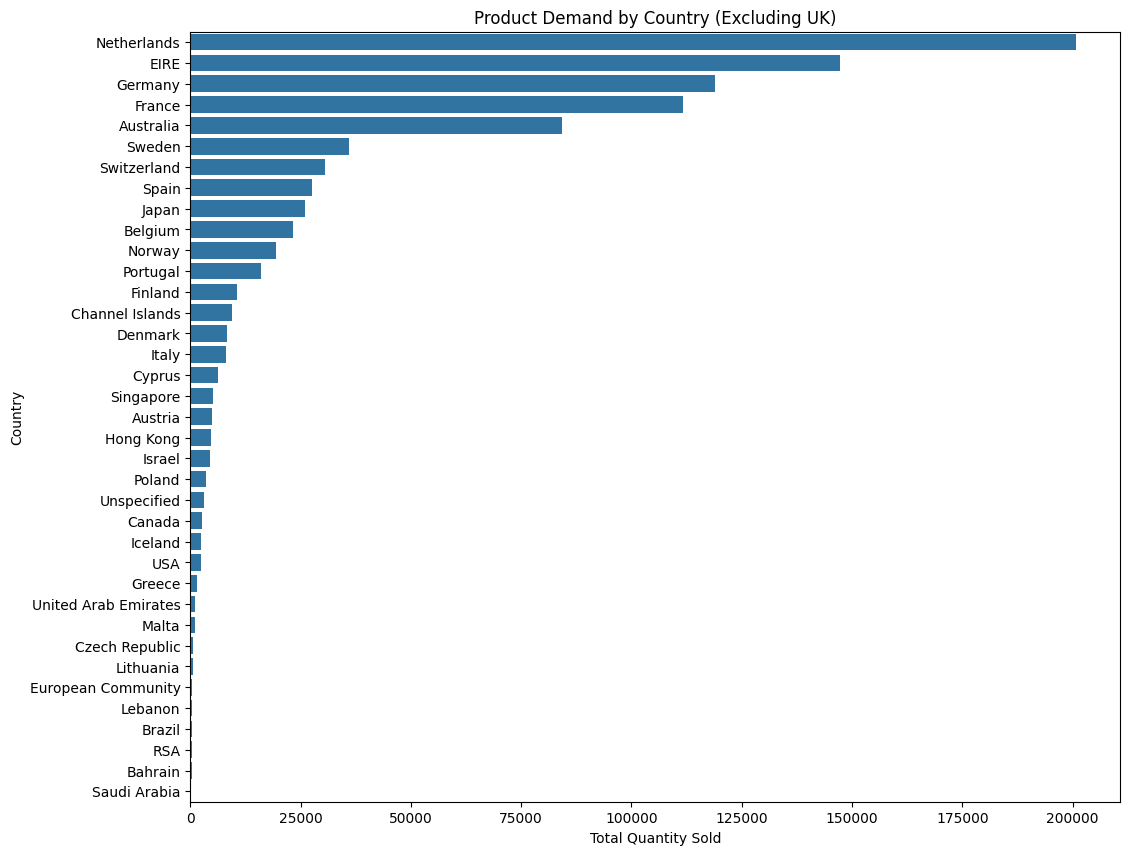

In [59]:
import seaborn as sns

# Filter out UK and group by Country
demand_by_country = df[df['Country'] != 'United Kingdom'].groupby('Country')['Quantity'].sum().sort_values(ascending=False)

# Plotting all countries in one view
plt.figure(figsize=(12, 10))
sns.barplot(x=demand_by_country.values, y=demand_by_country.index)
plt.title('Product Demand by Country (Excluding UK)')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Country')
plt.show()

#Insight: Volume (Quantity) generally correlates with Revenue, but some countries show higher volume with lower revenue, suggesting they purchase lower-margin or cheaper items in bulk.

# Saving the processed and cleaned dataset to Cleaned_Online_Retail.csv for further reporting or modeling.

In [62]:
df.to_csv('Cleaned_Online_Retail.csv', index=False)

# Conclusion
The analysis reveals that while the United Kingdom remains the primary market, there is significant international traction in Northern Europe. The business experiences strong seasonality, with the final quarter of the year being critical for annual success. Furthermore, the presence of extreme outliers in quantity and high-value customers points toward a hybrid B2B/B2C business model.

# Business Recommendations
Targeted Retention: Develop a "VIP Loyalty Program" specifically for the Top 10 Customer IDs identified in your analysis. Losing even one of these accounts would significantly impact total revenue.

Logistics Optimization: Since the Netherlands, Germany, and Ireland are top performers, consider localized warehousing or optimized shipping routes in these regions to reduce delivery times and costs.

Inventory Preparation: Given the Q4 revenue spike, inventory levels should be ramped up by late August. Focus stock on the "Top unique StockCodes" to avoid stockouts during the November peak.

Market Expansion: Explore why France and Australia (lower in the top 10) have lower demand compared to the Netherlands and implement targeted marketing campaigns in those regions to bridge the gap.